# PHD Finger Protein 23 — Bioactivity Analysis Results

**Target:** PHD finger protein 23 (PHF23)  
**ChEMBL target:** CHEMBL2424508

This notebook is the results and visualization companion to `analysis_pipeline.py`. It runs the same reproducible analysis, then presents the processed data, activity classes, molecular descriptors, plots, model results (when justified), and data-driven conclusions.


## 1. Setup

Install the project dependencies if they are not already available. In Google Colab, uncomment and run the installation cell below.


In [1]:
# Uncomment in a fresh Colab environment:
# !pip install -r requirements.txt


## 2. Run the analysis pipeline


In [2]:
import analysis_pipeline as pipeline

# Run the complete PHF23 analysis.
pipeline.main()


Fetching ChEMBL IC50 data for PHD finger protein 23 (CHEMBL2424508)...
Retrieved 84 raw records.

Activity-class counts:
bioactivity_class
inactive    82
Name: count, dtype: int64
Regression skipped: insufficient informative observations (n=82, unique pIC50=2).

Finished. Results are in: C:\Users\petri\Desktop\Bioactivity-Data-Extraction\outputs
Plots: outputs/plots/
Conclusions: outputs/CONCLUSIONS.md


## 3. Load the processed results


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

OUTDIR = Path("outputs")
PLOTDIR = OUTDIR / "plots"

df = pd.read_csv(OUTDIR / "phf23_bioactivity_processed.csv")
print(f"Number of processed observations: {len(df)}")
display(df.head())


Number of processed observations: 82


,molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_relation,pchembl_value,bioactivity_class,pIC50,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL2424677,CCN1Cc2ccc(NC(=O)c3ccc(C(=O)N4CCC(C5CCCN5)CC4)...,10000.0,nM,>,NaN,inactive,5.0,537.708,5.6222,3,5
1,CHEMBL2426376,CCN1Cc2ccc(NC(=O)c3ccc(C(=O)N4CCC(C5CCCN5)CC4)...,10000.0,nM,>,NaN,inactive,5.0,537.708,5.6222,3,5
2,CHEMBL2426375,CCN1Cc2ccc(NC(=O)c3ccc(C(=O)N4CCC(C5CCCN5)CC4)...,10000.0,nM,>,NaN,inactive,5.0,446.595,3.8786,2,4
3,CHEMBL2426374,CCN1Cc2ccc(NC(=O)c3ccc(C(=O)N4CC5CCC(C4)C5N4CC...,10000.0,nM,>,NaN,inactive,5.0,472.633,4.2208,1,4
4,CHEMBL2426373,CCN1Cc2ccc(NC(=O)c3ccc(C(=O)N4CCC(N5CCCC5)CC4)...,10000.0,nM,>,NaN,inactive,5.0,446.595,3.9748,1,4


## 4. Bioactivity summary


In [4]:
class_counts = pd.read_csv(OUTDIR / "activity_class_counts.csv")
display(class_counts)

summary = pd.read_csv(OUTDIR / "numeric_summary.csv", index_col=0)
display(summary)


,class,count
0,inactive,82


,count,mean,std,min,25%,50%,75%,max
standard_value,82.0,16341.463415,9363.996604,10000.000000,10000.000000,10000.0000,30000.000000,30000.0000
pIC50,82.0,4.848718,0.223388,4.522879,4.522879,5.0000,5.000000,5.0000
MW,82.0,425.672963,71.449951,230.355000,364.856000,438.6160,466.670000,618.8670
LogP,82.0,3.313032,0.862828,1.505100,2.672300,3.2417,3.841375,5.6222
NumHDonors,82.0,0.317073,0.664404,0.000000,0.000000,0.0000,0.000000,3.0000
NumHAcceptors,82.0,4.000000,0.785674,2.000000,4.000000,4.0000,4.000000,6.0000


### Activity-class interpretation

Compounds are classified using the same thresholds as the analysis pipeline:

- **Active:** IC50 ≤ 1,000 nM
- **Intermediate:** 1,000 < IC50 < 10,000 nM
- **Inactive:** IC50 ≥ 10,000 nM

This classification provides an intuitive view of the potency distribution for PHF23.


## 5. Plots


### Bioactivity class distribution

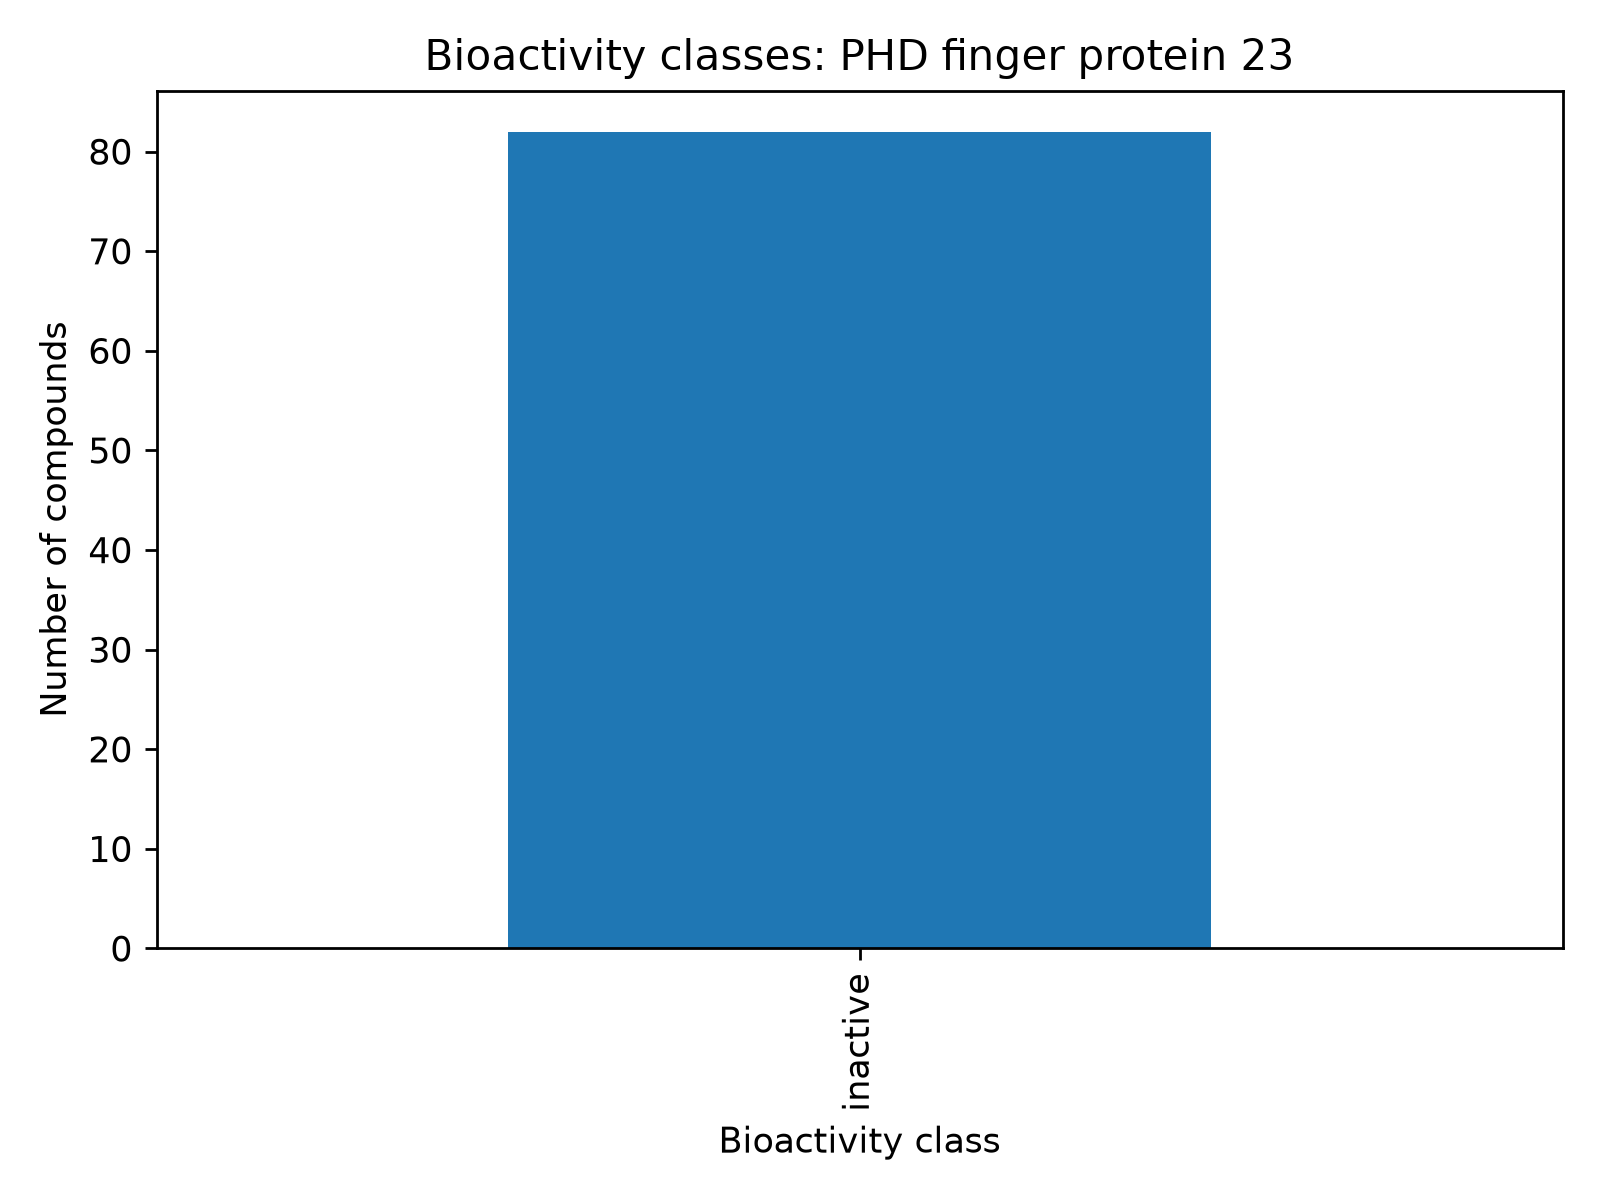

### pIC50 distribution

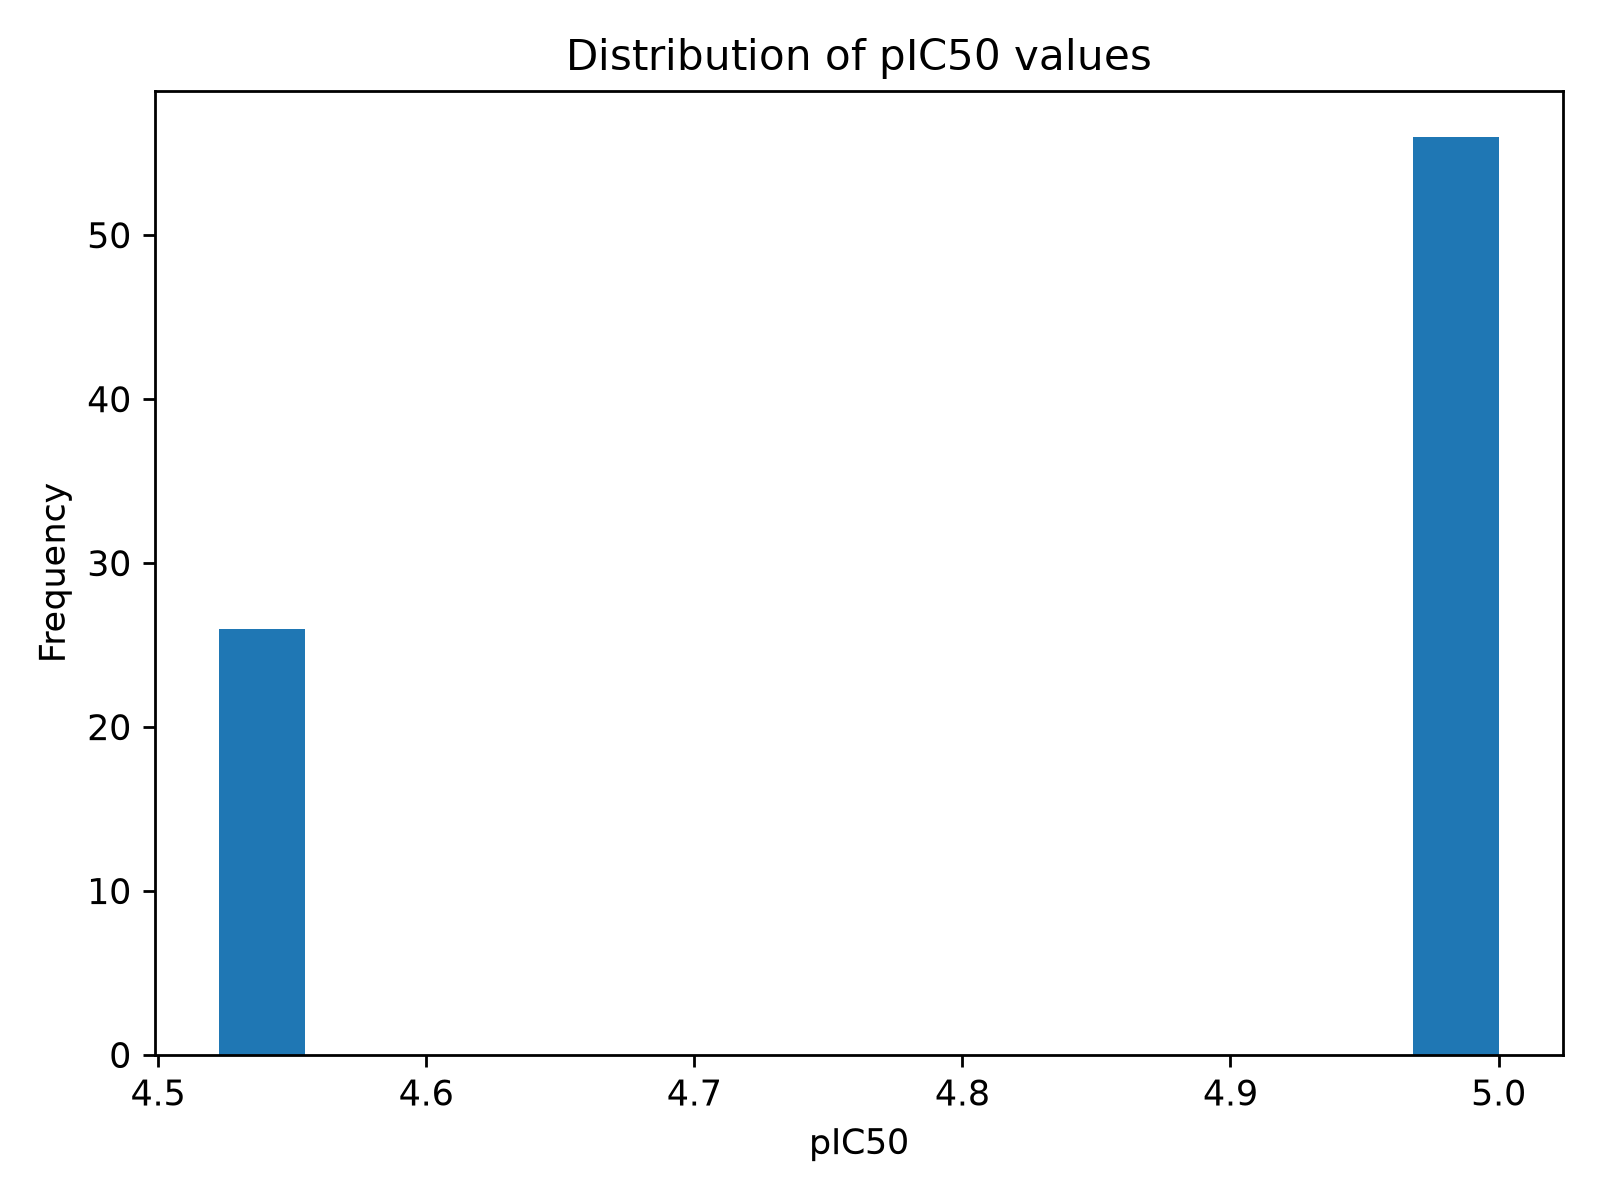

### Molecular weight vs pIC50

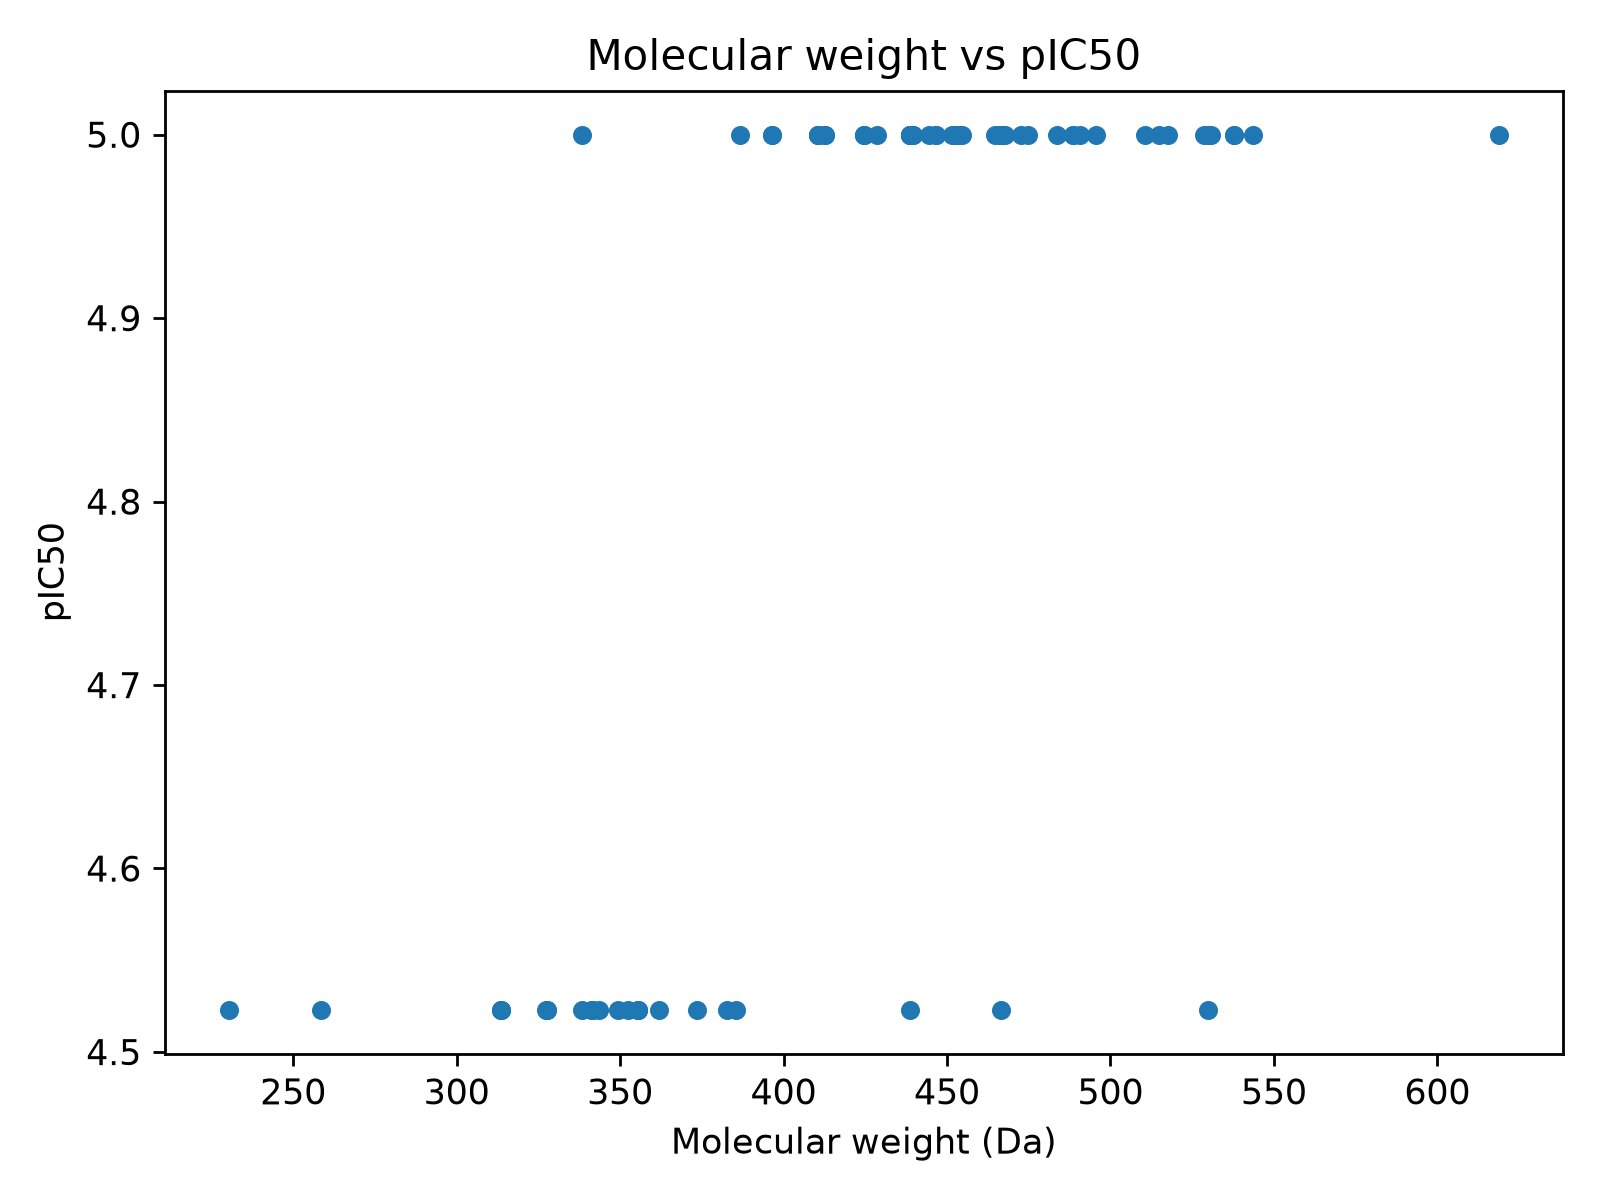

### LogP vs pIC50

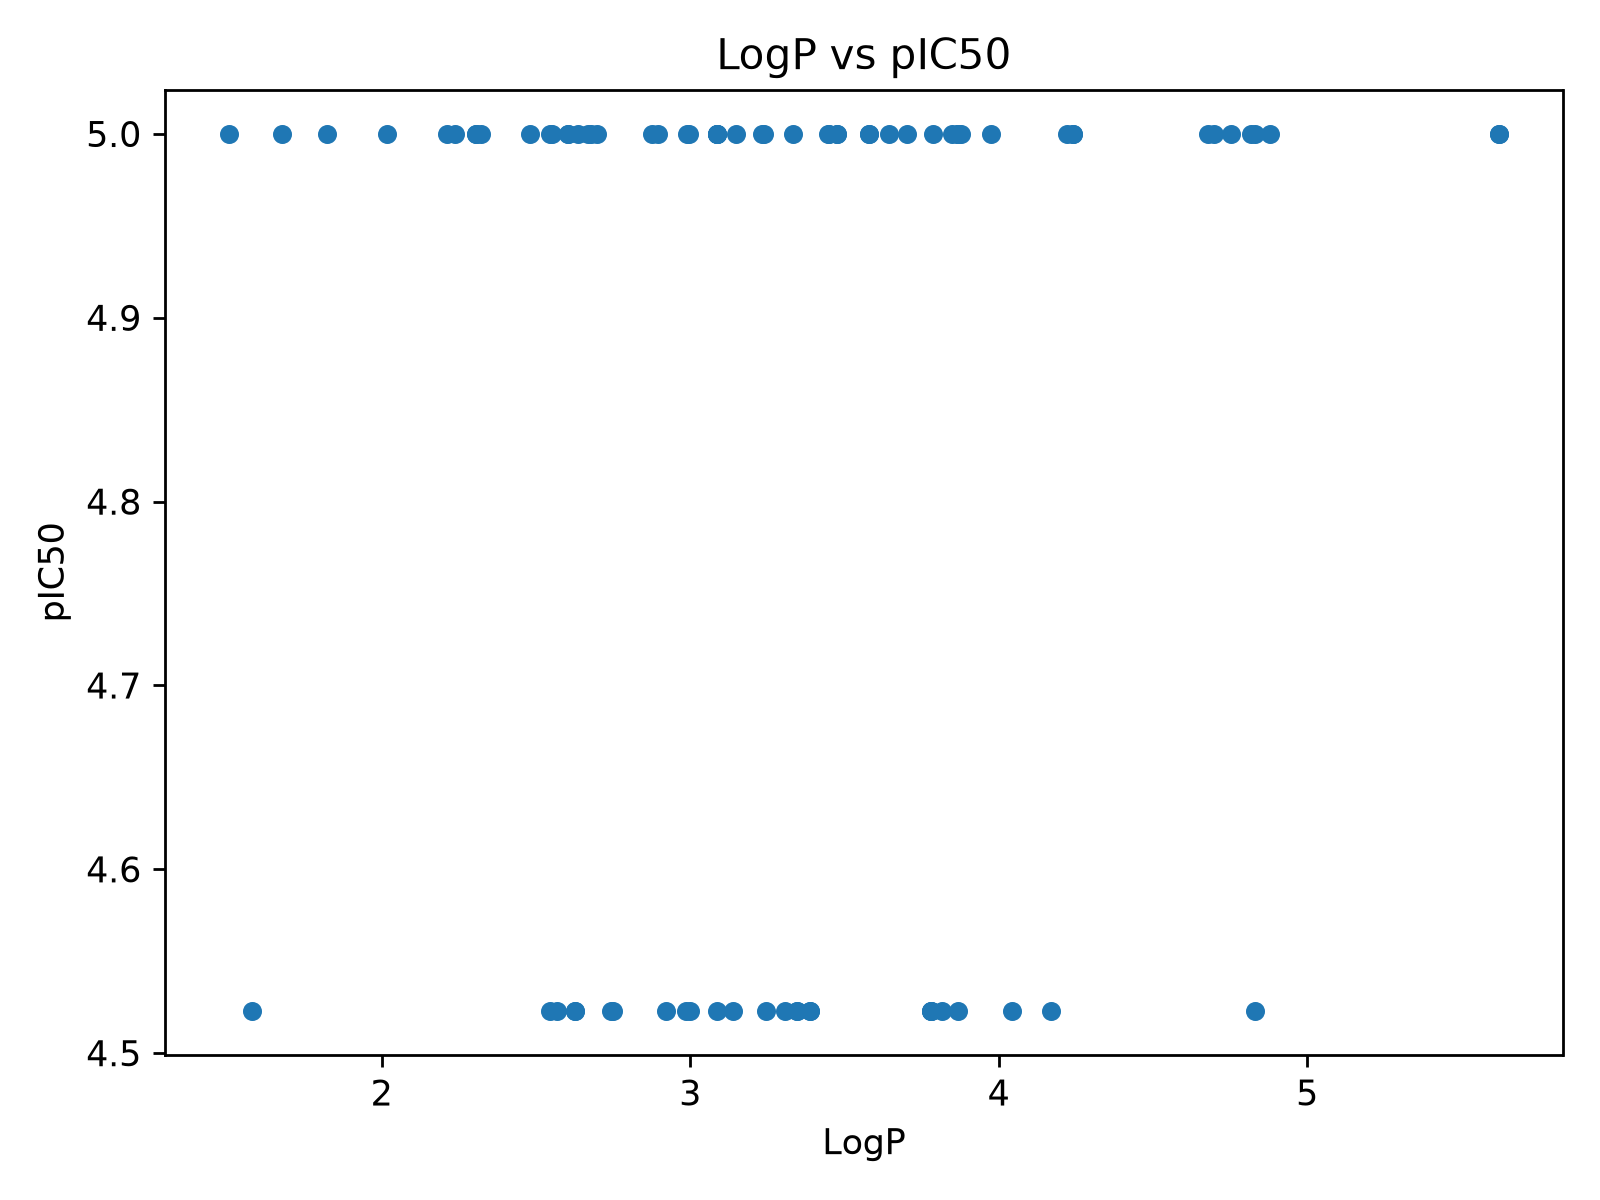

### Descriptor correlation matrix

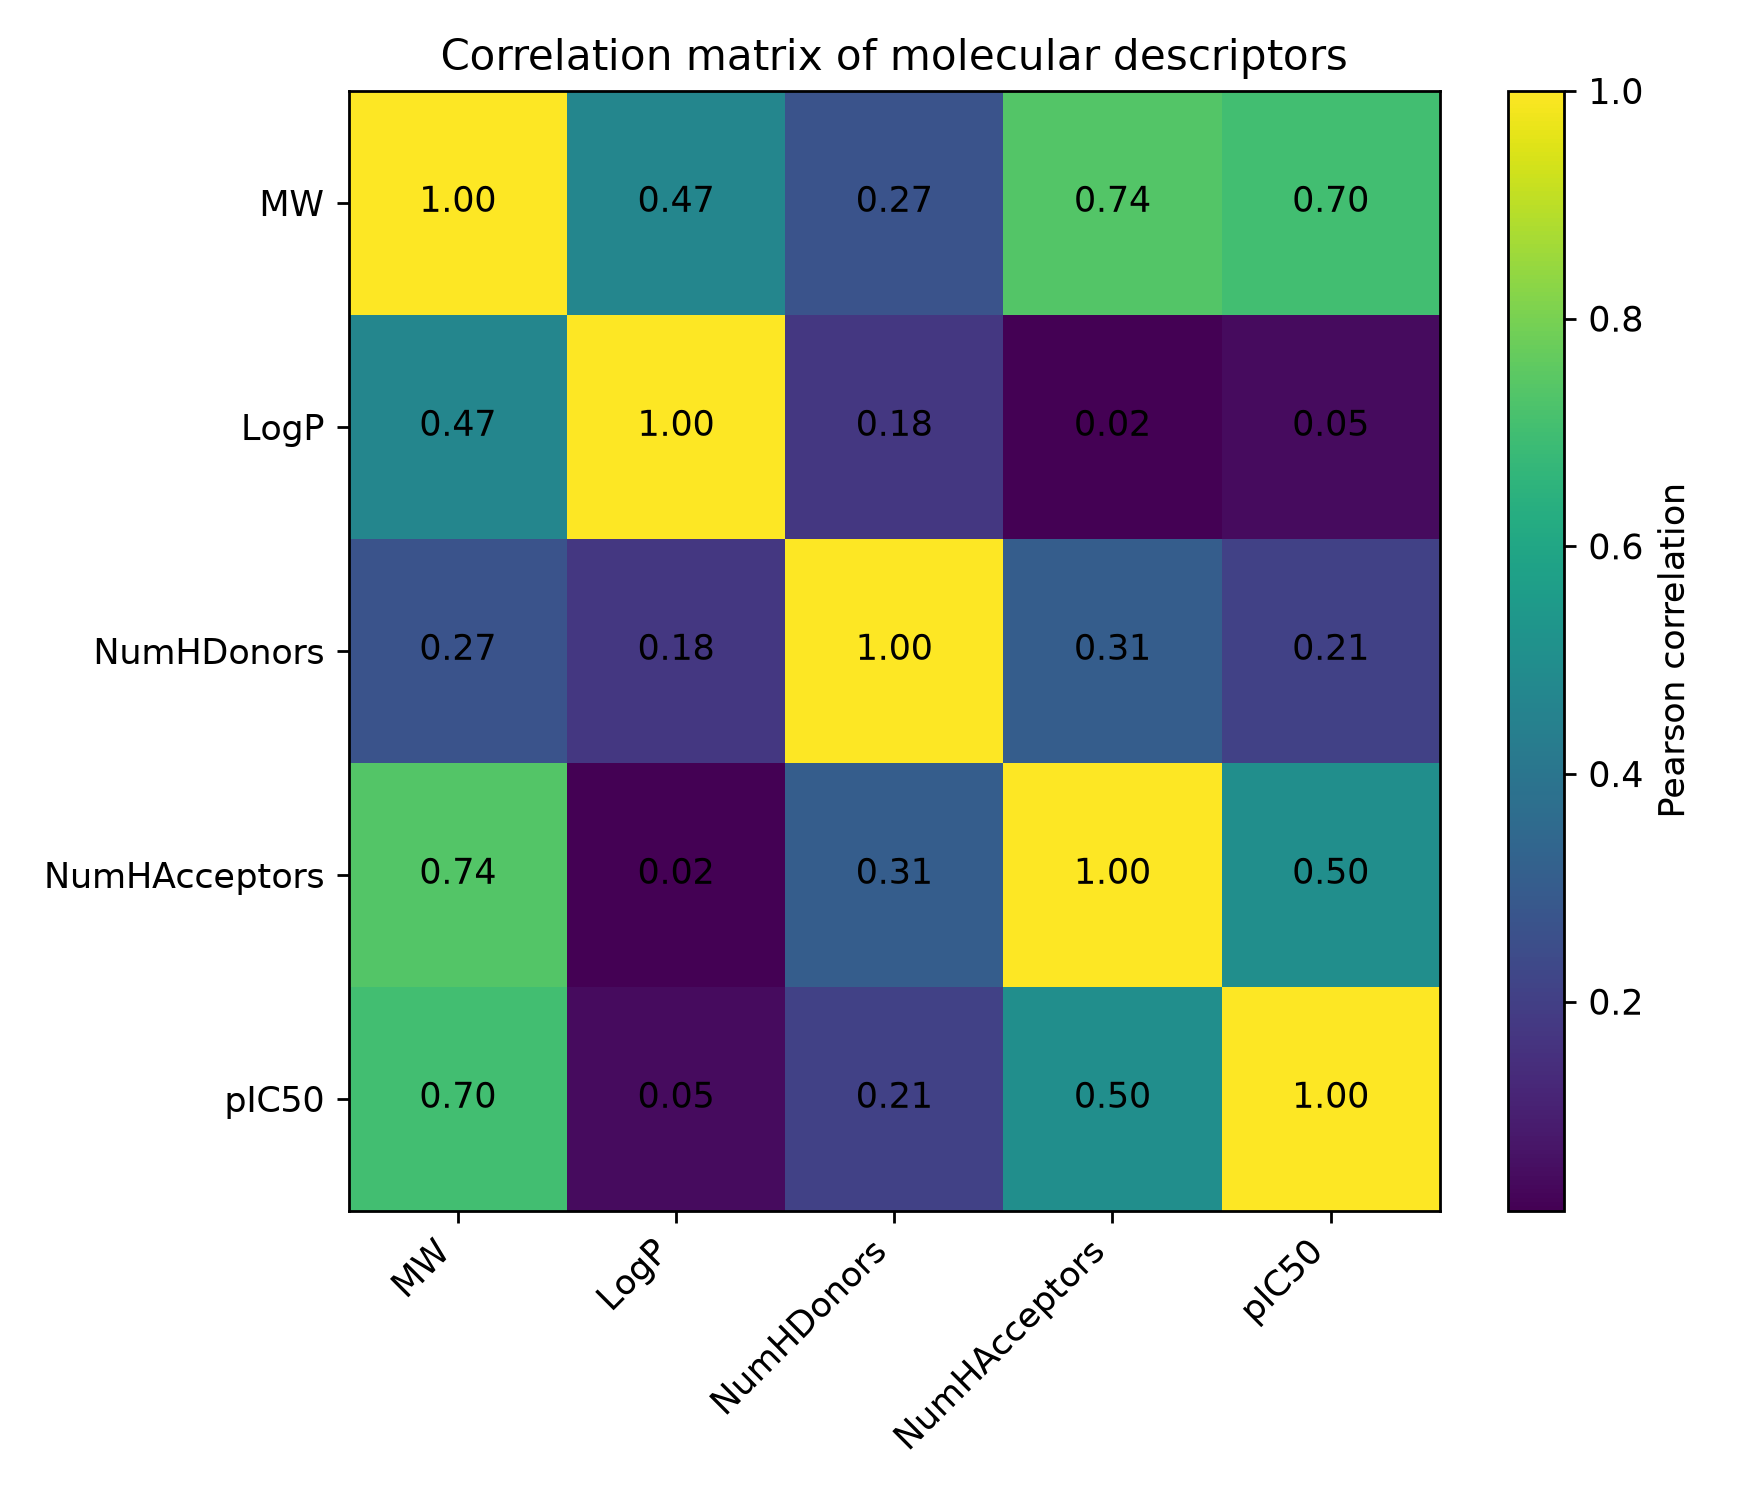

In [5]:
plot_files = [
    ("Bioactivity class distribution", "01_bioactivity_class_distribution.png"),
    ("pIC50 distribution", "02_pIC50_distribution.png"),
    ("Molecular weight vs pIC50", "03_MW_vs_pIC50.png"),
    ("LogP vs pIC50", "04_LogP_vs_pIC50.png"),
    ("Descriptor correlation matrix", "05_descriptor_correlation_matrix.png"),
]

for title, filename in plot_files:
    path = PLOTDIR / filename
    display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"{filename} was not generated for the available data.")


## 6. Lipinski molecular descriptors

The analysis calculates four commonly used physicochemical descriptors:

- **MW** — molecular weight
- **LogP** — octanol/water partition coefficient, related to lipophilicity
- **NumHDonors** — number of hydrogen-bond donors
- **NumHAcceptors** — number of hydrogen-bond acceptors

These descriptors help characterize the chemical space of the compounds and allow us to examine whether simple molecular properties are associated with PHF23 bioactivity.


In [6]:
descriptor_cols = ["MW", "LogP", "NumHDonors", "NumHAcceptors", "pIC50"]
available = [c for c in descriptor_cols if c in df.columns]
display(df[available].describe().T)

if len(available) > 1:
    display(df[available].corr())


,count,mean,std,min,25%,50%,75%,max
MW,82.0,425.672963,71.449951,230.355000,364.856000,438.6160,466.670000,618.8670
LogP,82.0,3.313032,0.862828,1.505100,2.672300,3.2417,3.841375,5.6222
NumHDonors,82.0,0.317073,0.664404,0.000000,0.000000,0.0000,0.000000,3.0000
NumHAcceptors,82.0,4.000000,0.785674,2.000000,4.000000,4.0000,4.000000,6.0000
pIC50,82.0,4.848718,0.223388,4.522879,4.522879,5.0000,5.000000,5.0000


,MW,LogP,NumHDonors,NumHAcceptors,pIC50
MW,1.000000,0.468467,0.266303,0.735127,0.701407
LogP,0.468467,1.000000,0.176224,0.016196,0.045124
NumHDonors,0.266303,0.176224,1.000000,0.307456,0.208116
NumHAcceptors,0.735127,0.016196,0.307456,1.000000,0.503422
pIC50,0.701407,0.045124,0.208116,0.503422,1.000000


## 7. Predictive modeling


In [7]:
metrics_file = OUTDIR / "random_forest_metrics.csv"
pred_file = OUTDIR / "random_forest_predictions.csv"

if metrics_file.exists():
    metrics = pd.read_csv(metrics_file)
    display(metrics)

    predictions = pd.read_csv(pred_file)
    ax = predictions.plot.scatter(x="observed_pIC50", y="predicted_pIC50", title="Observed vs predicted pIC50")
    ax.set_xlabel("Observed pIC50")
    ax.set_ylabel("Predicted pIC50")
    plt.show()
else:
    print("No regression results were generated. The pipeline deliberately skips modeling when the available dataset is too small or lacks sufficient pIC50 variation.")


No regression results were generated. The pipeline deliberately skips modeling when the available dataset is too small or lacks sufficient pIC50 variation.


## 8. Conclusions

The conclusions below are generated from the actual processed ChEMBL data, rather than being hard-coded. This is particularly important for PHF23 because the available bioactivity dataset may be small or strongly imbalanced.


In [8]:
conclusions_file = OUTDIR / "CONCLUSIONS.md"

if conclusions_file.exists():
    display(Markdown(conclusions_file.read_text(encoding="utf-8")))
else:
    print("CONCLUSIONS.md was not found. Run the pipeline cell above first.")


# Conclusions

This analysis examined **82 cleaned IC50 bioactivity records** for **PHD finger protein 23 (CHEMBL2424508)** retrieved from ChEMBL.

## Bioactivity profile

- Active compounds (IC50 <= 1,000 nM): **0**
- Intermediate compounds (1,000 < IC50 < 10,000 nM): **0**
- Inactive compounds (IC50 >= 10,000 nM): **82**

## Interpretation

The most common bioactivity class is **inactive**, representing **82/82 (100.0%)** of the processed observations.

The observed pIC50 values range from **4.52** to **5.00**, with a median of **5.00**.

## Main limitation

Only one bioactivity class is represented after preprocessing. Therefore, an active-vs-inactive classification model would not be scientifically meaningful for this data slice. This is a limitation of the available target data rather than a reason to manufacture or relabel observations.

## Overall conclusion

The workflow successfully converts raw ChEMBL measurements into a reproducible dataset containing activity classes, pIC50 values and molecular descriptors, together with plots that summarize the chemical and bioactivity space. The amount and diversity of available PHF23 bioactivity data should determine whether predictive modeling is justified. Future work could expand the dataset with additional compatible activity measurements or apply the same workflow to a target with a larger and better-balanced ChEMBL dataset.

## Generated plots

Plots are saved in `outputs/plots/` and include the bioactivity-class distribution, pIC50 distribution, molecular-weight/pIC50 relationship, LogP/pIC50 relationship and descriptor correlation matrix.

## 9. Final note

This project demonstrates a complete computational drug-discovery workflow from **ChEMBL bioactivity extraction** to **data preprocessing**, **pIC50 transformation**, **molecular descriptor calculation**, **exploratory visualization**, and **conditional predictive modeling**.

A major principle of the analysis is that machine-learning models are only fitted when the available PHF23 data support a meaningful analysis. Limited or imbalanced data are reported as a scientific limitation rather than being artificially modified to produce a model.
